In [68]:
# 1. Google Drive 마운트 (필요 시 실행)
# from google.colab import drive
# drive.mount('/content/drive')

# 2. 필수 외부 모듈 설치 (5주차용)
!pip install -q ucimlrepo

# 3. 공통 라이브러리 임포트
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from io import BytesIO
import requests

# 4. 한글 깨짐 및 마이너스 부호 설정 수정
# 나눔폰트 관련 경고를 피하기 위해 기본 폰트를 사용하거나 폰트 설정을 초기화합니다.
plt.rc('font', family='sans-serif')
# 그래프에서 마이너스(-) 부호가 깨지는 것을 방지합니다.
plt.rcParams['axes.unicode_minus'] = False

# 사이킷런 관련 모듈
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, QuantileTransformer
from sklearn.linear_model import LinearRegression, LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier, AdaBoostClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, confusion_matrix, classification_report, log_loss
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.datasets import load_wine, load_breast_cancer
from ucimlrepo import fetch_ucirepo

In [69]:
# ==========================================
# 02주차. 머신러닝 데이터분석 (Numpy)
# ==========================================

# [문제 1] 넘파이 배열 마스킹 및 필터링
np.random.seed(42)
scores = np.random.randint(0, 101, size=10)
print(f"원본 점수: {scores}")

high_scores = scores[scores >= 80]
print(f"80점 이상: {high_scores}")

scores[scores < 60] = 0
print(f"과락 처리 후: {scores}")

results = np.where(scores >= 80, 'Pass', 'Fail')
print(f"합격 여부: {results}")

원본 점수: [51 92 14 71 60 20 82 86 74 74]
80점 이상: [92 82 86]
과락 처리 후: [ 0 92  0 71 60  0 82 86 74 74]
합격 여부: ['Fail' 'Pass' 'Fail' 'Fail' 'Fail' 'Fail' 'Pass' 'Pass' 'Fail' 'Fail']


In [70]:
# ==========================================
# 02주차. 머신러닝 데이터분석 (Numpy)
# ==========================================

# [문제 2] 브로드캐스팅을 활용한 데이터 정규화
# 키, 몸무게 데이터
data = np.array([
    [175, 70],
    [180, 82],
    [160, 55],
    [165, 60],
    [170, 72]
])

mean = np.mean(data, axis=0)
std = np.std(data, axis=0)

standardized_data = (data - mean) / std

print("1. 각 항목별 평균:\n", mean)
print("\n2. 표준화된 데이터 (평균 0, 표준편차 1):\n", standardized_data)
print("\n3. 표준화 후 평균 확인 (0에 수렴):\n", np.mean(standardized_data, axis=0))

1. 각 항목별 평균:
 [170.   67.8]

2. 표준화된 데이터 (평균 0, 표준편차 1):
 [[ 0.70710678  0.23221018]
 [ 1.41421356  1.49881117]
 [-1.41421356 -1.35104106]
 [-0.70710678 -0.82329065]
 [ 0.          0.44331035]]

3. 표준화 후 평균 확인 (0에 수렴):
 [0.00000000e+00 3.10862447e-16]


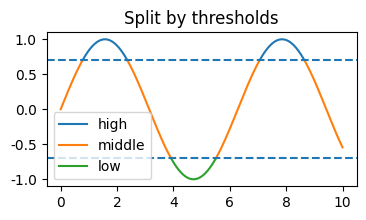

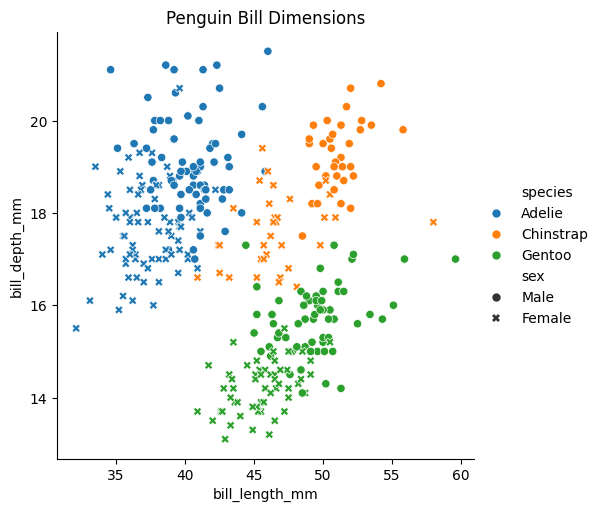

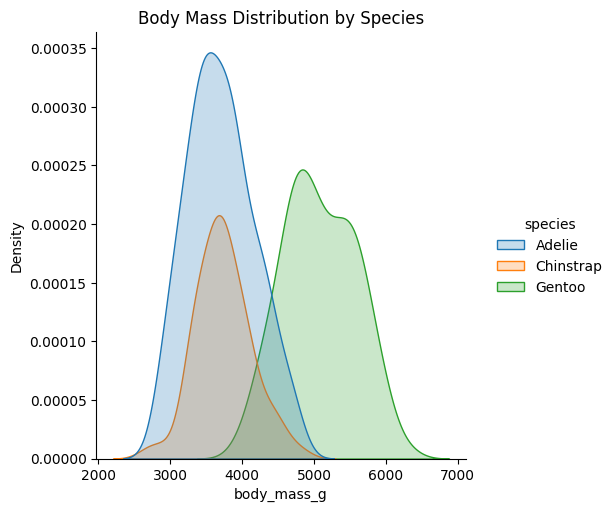

In [71]:
# ==========================================
# 03주차. 머신러닝 데이터 시각화
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# [문제 1] Matplotlib 활용 예제 (마스킹 시각화)
x = np.linspace(0, 10, 500)
y = np.sin(x)

upper = 0.7
lower = -0.7

# 임계값에 따른 마스킹 처리
y_up = np.ma.masked_where(y < upper, y)
y_mid = np.ma.masked_where((y < lower) | (y > upper), y)
y_low = np.ma.masked_where(y > lower, y)

plt.figure(figsize=(4, 2))
plt.plot(x, y_up, label="high")
plt.plot(x, y_mid, label="middle")
plt.plot(x, y_low, label="low")

# 가이드 라인 (-- 점선) 추가
plt.axhline(upper, linestyle="--")
plt.axhline(lower, linestyle="--")

plt.title("Split by thresholds")
plt.legend()
plt.show()

# [문제 2] Seaborn 활용 예제 (펭귄 데이터 분석)
penguins = sns.load_dataset("penguins")

# 1. 종별 색상, 성별 마커 모양 다르게 시각화 (relplot)
sns.relplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    style="sex"
)
plt.title("Penguin Bill Dimensions")
plt.show()

# 2. 몸무게 분포를 종별 KDE(밀도 그래프)로 비교 시각화 (displot)
sns.displot(
    data=penguins,
    x="body_mass_g",
    hue="species",
    kind="kde",
    fill=True
)
plt.title("Body Mass Distribution by Species")
plt.show()

In [72]:
diamond = pd.read_csv('/content/drive/MyDrive/diamonds.csv')
diamond.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75



훈련 세트 점수(R2): 0.8538
테스트 세트 점수(R2): 0.8532


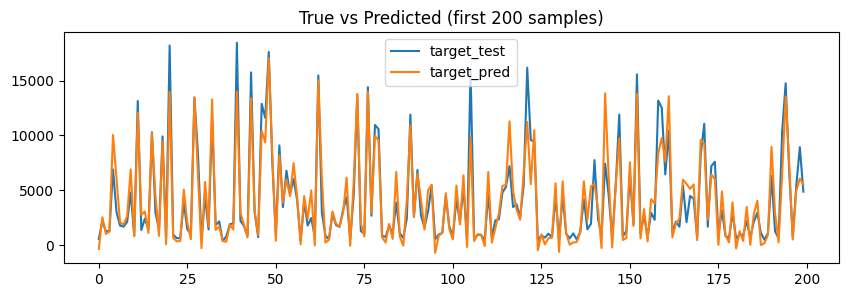

In [73]:
# ==========================================
# 04주차. Linear Regression
# ==========================================

# 2. 특성(X)과 타겟(y) 설정
# 이미지 예제 기준: table, depth, carat으로 price 예측
X = diamond[['table', 'depth', 'carat']]
y = diamond['price']

# 3. 데이터 분할 (학습용 80%, 테스트용 20%)
train_features, test_features, train_labels, test_labels = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. 데이터 표준화 (StandardScaler)
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
test_features = scaler.transform(test_features)

# 5. 모델 학습 및 평가
reg = LinearRegression()
reg.fit(train_features, train_labels)

print(f"\n훈련 세트 점수(R2): {reg.score(train_features, train_labels):.4f}")
print(f"테스트 세트 점수(R2): {reg.score(test_features, test_labels):.4f}")

# 6. 예측 결과 시각화 (첫 200개 샘플 비교)
N = 200
target_test = test_labels.values
target_pred = reg.predict(test_features)

plt.figure(figsize=(10, 3))
plt.plot(target_test[:N], label="target_test")
plt.plot(target_pred[:N], label="target_pred")
plt.legend(loc="upper center")
plt.title(f"True vs Predicted (first {N} samples)")
plt.show()

In [74]:
# 1. 데이터셋 불러오기 (AI4I 2020 Predictive Maintenance)
# ucimlrepo 패키지를 사용하여 직접 데이터를 가져옵니다.
data = fetch_ucirepo(id=601)

# 특성(X)과 타겟(y) 설정 - **수정된 열 이름 사용**
X = data.data.features[['Air temperature', 'Process temperature', 'Rotational speed', 'Torque']]
y = data.data.targets.iloc[:, 0] # Machine failure 여부
X.head(3)

,Air temperature,Process temperature,Rotational speed,Torque
0,298.1,308.6,1551,42.8
1,298.2,308.7,1408,46.3
2,298.1,308.5,1498,49.4


In [75]:
y.head(3)

,Machine failure
0,0
1,0
2,0


In [76]:
# ==========================================
# 05주차. Logistic Regression
# ==========================================

# 2. 데이터 분할 (학습용 80%, 테스트용 20%)
# 'Type' 컬럼을 원-핫 인코딩하여 수치형으로 변환
# 2. 데이터 분할 (학습용 80%, 테스트용 20%)
train_features, test_features, train_labels, test_labels = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. 데이터 표준화
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
test_features = scaler.transform(test_features)

# 4. 모델 생성 및 학습
clf = LogisticRegression()
clf.fit(train_features, train_labels)

# 5. 성능 평가 결과 출력
print(f"\n훈련 세트 점수: {clf.score(train_features, train_labels):}")
print(f"테스트 세트 점수: {clf.score(test_features, test_labels):}")
print(f"회귀 계수(coef_): \n{clf.coef_}")


훈련 세트 점수: 0.971125
테스트 세트 점수: 0.9725
회귀 계수(coef_): 
[[ 1.43689864 -0.98274843  1.85544821  2.52457278]]


In [77]:
# 이미지 예시 입력값: 456, 259, 1654, 67
air = float(input("공기 온도를 입력하세요: "))
proc = float(input("공정 온도를 입력하세요: "))
rpm = float(input("회전 속도를 입력하세요: "))
torq = float(input("토크를 입력하세요: "))

# 입력 데이터를 데이터프레임으로 변환 후 스케일링
sample = pd.DataFrame([[air, proc, rpm, torq]], columns=X.columns)
sample_scaled = scaler.transform(sample)

# 예측 실행
pred = clf.predict(sample_scaled)[0]
if pred == 1:
    print("결과: 고장 위험입니다.")
else:
    print("결과: 정상(비고장)으로 예측됩니다.")

공기 온도를 입력하세요: 456
공정 온도를 입력하세요: 259
회전 속도를 입력하세요: 1654
토크를 입력하세요: 67
결과: 고장 위험입니다.


In [78]:
# 1. 데이터 로드 (업로드한 BankNote_Authentication.csv 사용)
# 파일이 코랩 루트 폴더에 있어야 합니다.
data = pd.read_csv('/content/drive/MyDrive/BankNote_Authentication.csv')
data.head(2)

,variance,skewness,curtosis,entropy,class
0,3.6216,8.6661,-2.8073,-0.44699,0
1,4.5459,8.1674,-2.4586,-1.46210,0


In [79]:
# ==========================================
# 06주차. Decision Tree
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_graphviz
import graphviz

# 1. 데이터 로드 (업로드한 BankNote_Authentication.csv 사용)
# 파일이 코랩 루트 폴더에 있어야 합니다.
data = pd.read_csv('/content/drive/MyDrive/BankNote_Authentication.csv')

# 2. 특성(X)과 타겟(y) 설정
X = data.drop(columns=['class'])
y = data['class']

# 3. 데이터 분할 (학습용 80%, 테스트용 20%)
train_features, test_features, train_labels, test_labels = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. 데이터 표준화
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
test_features = scaler.transform(test_features)

# 5. 모델 생성 및 학습 (기본 설정: max_depth=3)
clf_tree = DecisionTreeClassifier(max_depth=3, random_state=1)
clf_tree.fit(train_features, train_labels)

print(f"훈련 세트 점수: {clf_tree.score(train_features, train_labels):}")
print(f"테스트 세트 점수: {clf_tree.score(test_features, test_labels):}")

훈련 세트 점수: 0.9425706472196901
테스트 세트 점수: 0.9090909090909091


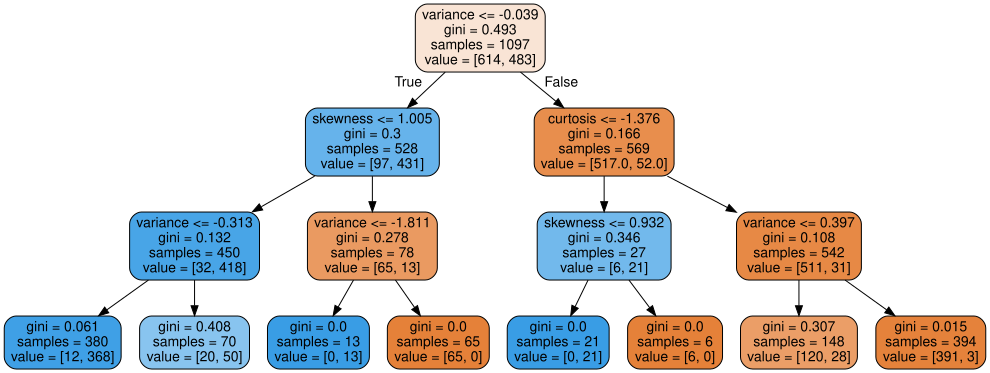


[깊이별 성능 변화]
max_depth=2: 0.9252506836827712 0.88
max_depth=3: 0.9425706472196901 0.9090909090909091
max_depth=4: 0.9653600729261622 0.9345454545454546
max_depth=5: 0.9872379216043756 0.9672727272727273


In [80]:
# 6. 트리 시각화 (Graphviz 사용)
# !pip install graphviz (설치가 안 되어 있을 경우 실행)
dot_data = export_graphviz(clf_tree, out_file=None,
                           feature_names=list(X.columns),
                           filled=True, rounded=True)
graph = graphviz.Source(dot_data)
display(graph) # 코랩에서 트리 구조 출력

# 7. 트리의 깊이(max_depth) 변화에 따른 성능 비교
print("\n[깊이별 성능 변화]")
for depth in range(2, 6):
    tmp = DecisionTreeClassifier(max_depth=depth, random_state=1)
    tmp.fit(train_features, train_labels)

    train_acc = tmp.score(train_features, train_labels)
    test_acc = tmp.score(test_features, test_labels)

    print(f"max_depth={depth}: {train_acc:} {test_acc:}")

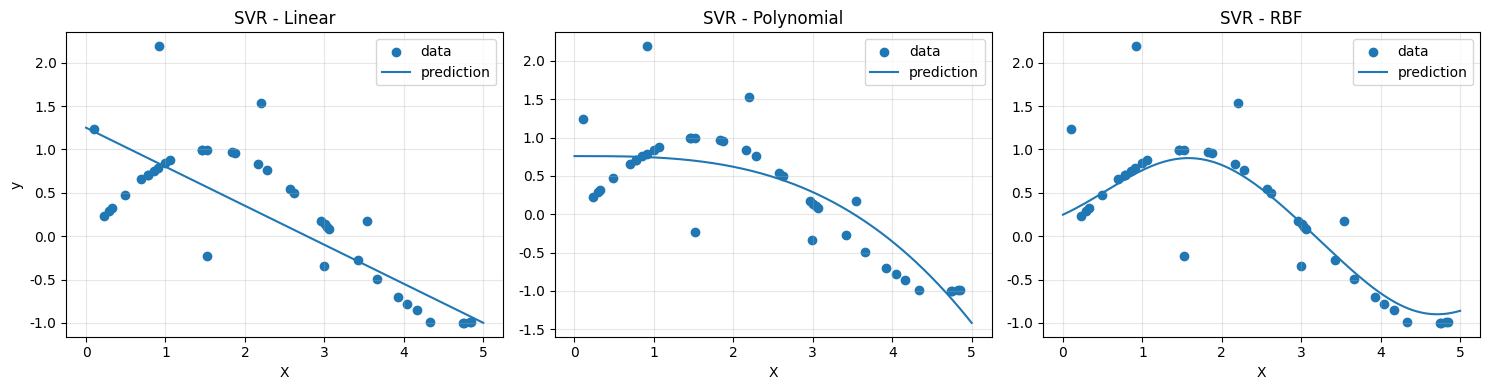

In [81]:
# ==========================================
# 07주차. Support Vector Machine
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR

# 1. 데이터셋 생성
np.random.seed(42)
X = np.sort(5 * np.random.rand(40, 1), axis=0)
y = np.sin(X).ravel()

# 데이터에 노이즈 추가
y[::5] += 3 * (0.5 - np.random.rand(8))

# 예측을 위한 테스트 데이터 생성
X_plot = np.linspace(0, 5, 500).reshape(-1, 1)

# 2. SVR 모델 생성 및 학습 (3가지 커널 비교)
svr_linear = SVR(kernel="linear", C=1.0)
svr_poly = SVR(kernel="poly", degree=3, C=1.0, gamma="scale")
svr_rbf = SVR(kernel="rbf", C=1.0, gamma="scale")

svr_linear.fit(X, y)
svr_poly.fit(X, y)
svr_rbf.fit(X, y)

# 3. 예측 실행
y_linear = svr_linear.predict(X_plot)
y_poly = svr_poly.predict(X_plot)
y_rbf = svr_rbf.predict(X_plot)

# 4. 결과 시각화 (1행 3열 서브플롯)
plt.figure(figsize=(15, 4))

# SVR - Linear
plt.subplot(1, 3, 1)
plt.scatter(X, y, label="data")
plt.plot(X_plot, y_linear, label="prediction")
plt.title("SVR - Linear")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True, alpha=0.3)
plt.legend()

# SVR - Polynomial
plt.subplot(1, 3, 2)
plt.scatter(X, y, label="data")
plt.plot(X_plot, y_poly, label="prediction")
plt.title("SVR - Polynomial")
plt.xlabel("X")
plt.grid(True, alpha=0.3)
plt.legend()

# SVR - RBF
plt.subplot(1, 3, 3)
plt.scatter(X, y, label="data")
plt.plot(X_plot, y_rbf, label="prediction")
plt.title("SVR - RBF")
plt.xlabel("X")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

최적 k: 4, Test Accuracy: 0.9649


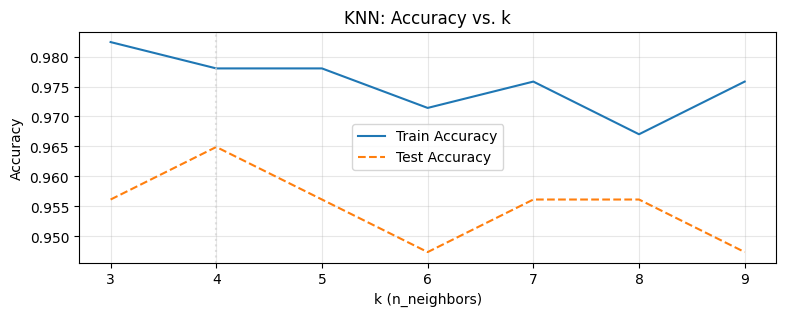

In [82]:
# ==========================================
# 09주차. K-Nearest Neighbor (KNN)
# ==========================================

# 1. 데이터 로드 및 분할
feature, target = load_breast_cancer(return_X_y=True, as_frame=True)
feature_train, feature_test, target_train, target_test = train_test_split(
    feature, target, test_size=0.2, random_state=0
)

# 2. 데이터 표준화
scaler = StandardScaler()
feature_train = scaler.fit_transform(feature_train)
feature_test = scaler.transform(feature_test)

# 3. 최적의 k(n_neighbors) 찾기 루프
k_list = list(range(3, 10))
train_acc_list = []
test_acc_list = []
best_k = None
best_test_acc = 0

for k in k_list:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(feature_train, target_train)

    # 예측 및 정확도 계산
    pred_train = knn.predict(feature_train)
    pred_test = knn.predict(feature_test)

    train_acc = accuracy_score(target_train, pred_train)
    test_acc = accuracy_score(target_test, pred_test)

    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)

    # 최적의 k 업데이트
    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_k = k

print(f"최적 k: {best_k}, Test Accuracy: {best_test_acc:.4f}")

# 4. 결과 시각화 (KNN: Accuracy vs. k)
plt.figure(figsize=(9, 3))
plt.plot(k_list, train_acc_list, label="Train Accuracy")
plt.plot(k_list, test_acc_list, label="Test Accuracy", linestyle="--")

# 최적의 k 지점에 수직 점선 표시
plt.axvline(best_k, color='lightgray', linestyle=":", alpha=0.7)

plt.title("KNN: Accuracy vs. k")
plt.xlabel("k (n_neighbors)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [83]:
# ==========================================
# 10주차. 학습 알고리즘 최적화
# ==========================================

# 1. 데이터 로드 및 분할
cancer = load_breast_cancer()
train_features, test_features, train_labels, test_labels = train_test_split(
    cancer.data, cancer.target, test_size=0.2, random_state=42
)

# 2. 데이터 표준화
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)
test_features = scaler.transform(test_features)

# 3. 일반적인 fit() 호출 시 정확도 확인
max_iter = 100
sgd_default = SGDClassifier(loss='log_loss', max_iter=max_iter, tol=1e-3)
sgd_default.fit(train_features, train_labels)
print(f"fit() 학습 정확도: {accuracy_score(test_labels, sgd_default.predict(test_features)):.4f}\n")

# 4. partial_fit()을 이용한 에폭별 손실 기록
sgd = SGDClassifier(loss='log_loss', random_state=42)
train_losses = []
test_losses = []

print("에폭별 손실 변화 기록 중...")
for epoch in range(max_iter):
    # 각 에폭마다 점진적 학습 수행
    sgd.partial_fit(train_features, train_labels, classes=np.unique(train_labels))

    # 현재 에폭에서의 손실(Log Loss) 계산
    train_loss = log_loss(train_labels, sgd.predict_proba(train_features))
    test_loss = log_loss(test_labels, sgd.predict_proba(test_features))

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    print(f"에폭 {epoch+1}: Train Loss = {train_loss:.4f} Test Loss = {test_loss:.4f}")

print(f"\npartial_fit() 최종 정확도: {accuracy_score(test_labels, sgd.predict(test_features)):.4f}")

fit() 학습 정확도: 0.9737

에폭별 손실 변화 기록 중...
에폭 1: Train Loss = 0.8298 Test Loss = 1.2333
에폭 2: Train Loss = 0.7475 Test Loss = 1.2337
에폭 3: Train Loss = 0.6339 Test Loss = 0.6759
에폭 4: Train Loss = 0.7155 Test Loss = 0.4397
에폭 5: Train Loss = 0.4229 Test Loss = 0.8726
에폭 6: Train Loss = 0.3896 Test Loss = 0.6123
에폭 7: Train Loss = 0.4328 Test Loss = 0.3975
에폭 8: Train Loss = 0.2753 Test Loss = 0.3818
에폭 9: Train Loss = 0.2575 Test Loss = 0.4169
에폭 10: Train Loss = 0.2404 Test Loss = 0.5454
에폭 11: Train Loss = 0.3249 Test Loss = 0.5152
에폭 12: Train Loss = 0.2059 Test Loss = 0.5047
에폭 13: Train Loss = 0.2110 Test Loss = 0.4080
에폭 14: Train Loss = 0.1999 Test Loss = 0.4951
에폭 15: Train Loss = 0.1513 Test Loss = 0.4808
에폭 16: Train Loss = 0.1130 Test Loss = 0.3628
에폭 17: Train Loss = 0.1516 Test Loss = 0.4429
에폭 18: Train Loss = 0.1079 Test Loss = 0.2673
에폭 19: Train Loss = 0.2776 Test Loss = 0.3460
에폭 20: Train Loss = 0.1146 Test Loss = 0.4276
에폭 21: Train Loss = 0.1529 Test Loss = 0.3405
에폭 

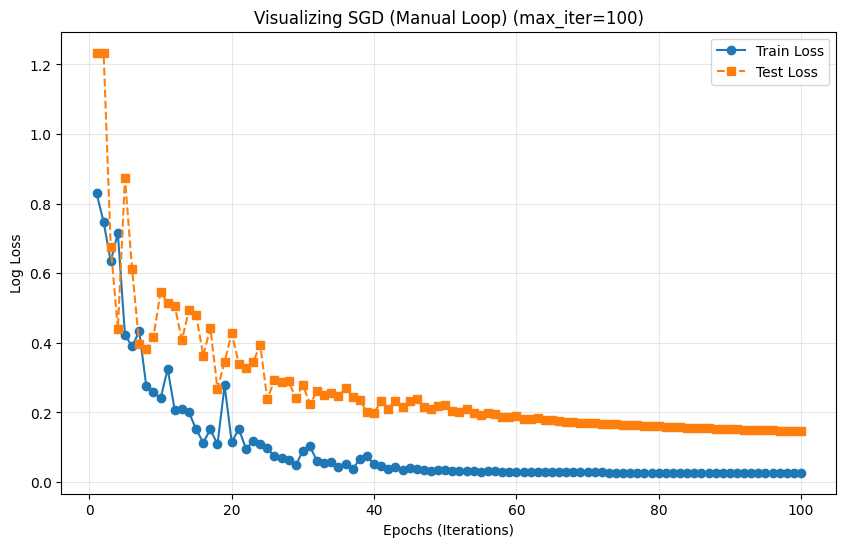

In [84]:
# 5. 결과 시각화
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_iter + 1), train_losses, 'o-', label='Train Loss')
plt.plot(range(1, max_iter + 1), test_losses, 's--', label='Test Loss')

plt.title(f'Visualizing SGD (Manual Loop) (max_iter={max_iter})')
plt.xlabel('Epochs (Iterations)')
plt.ylabel('Log Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (178). n_quantiles is set to n_samples.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (178). n_quantiles is set to n_samples.
  warnings.warn(


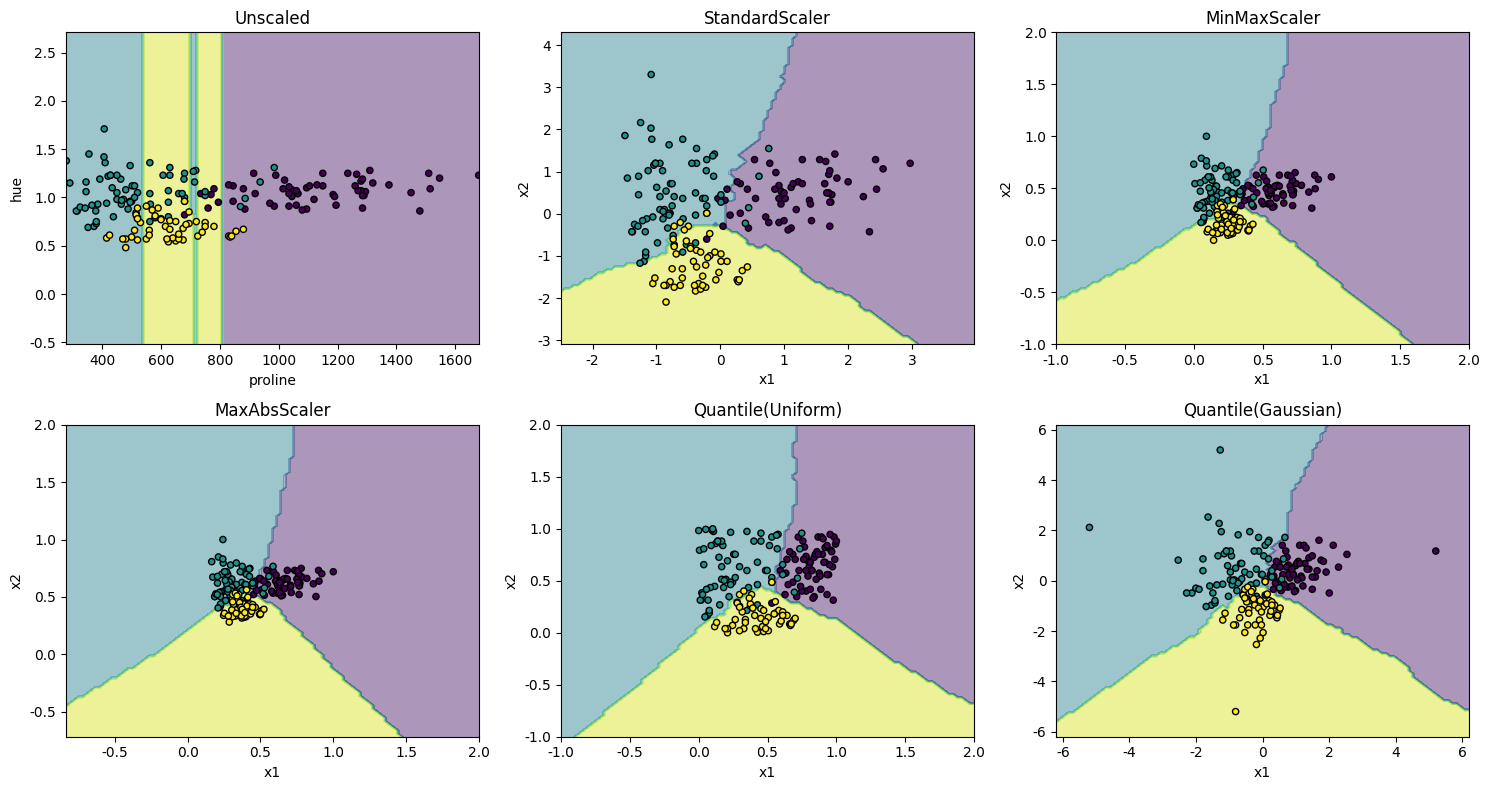

In [85]:
# 1. 데이터 로드 및 특성 선택 (proline, hue 두 가지만 사용)
X, y = load_wine(return_X_y=True, as_frame=True)
X2 = X[["proline", "hue"]]

# 2. 비교할 스케일러 목록 정의
scalers = [
    ("Unscaled", None),
    ("StandardScaler", StandardScaler()),
    ("MinMaxScaler", MinMaxScaler()),
    ("MaxAbsScaler", MaxAbsScaler()),
    ("Quantile(Uniform)", QuantileTransformer(output_distribution="uniform")),
    ("Quantile(Gaussian)", QuantileTransformer(output_distribution="normal")),
]

# 3. 모델 설정 (이웃 수 = 20)
knn = KNeighborsClassifier(n_neighbors=20)

# 4. 시각화 설정 (2행 3열 서브플롯)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

# 5. 각 스케일러별 루프 실행
for ax, (name, scaler) in zip(axes, scalers):
    if scaler is None:
        # 스케일링을 하지 않은 경우
        knn.fit(X2, y)
        DecisionBoundaryDisplay.from_estimator(
            knn, X2, response_method="predict", alpha=0.45, ax=ax
        )
        ax.scatter(X2["proline"], X2["hue"], c=y, s=20, edgecolor="k")
        ax.set_xlabel("proline")
        ax.set_ylabel("hue")
    else:
        # 스케일링 적용
        X_scaled = scaler.fit_transform(X2)
        # DecisionBoundaryDisplay를 위해 다시 DataFrame 형태로 변환하거나 넘파이 인덱싱 사용
        knn.fit(X_scaled, y)
        DecisionBoundaryDisplay.from_estimator(
            knn, X_scaled, response_method="predict", alpha=0.45, ax=ax
        )
        ax.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y, s=20, edgecolor="k")
        ax.set_xlabel("x1")
        ax.set_ylabel("x2")

    ax.set_title(name)

plt.tight_layout()
plt.show()


[예제 1: 배달 시간 예측 성능 분석]
평균 절대 오차 (MAE): 8.5분
예측 모델의 신뢰도 (R2 Score): 26.8%


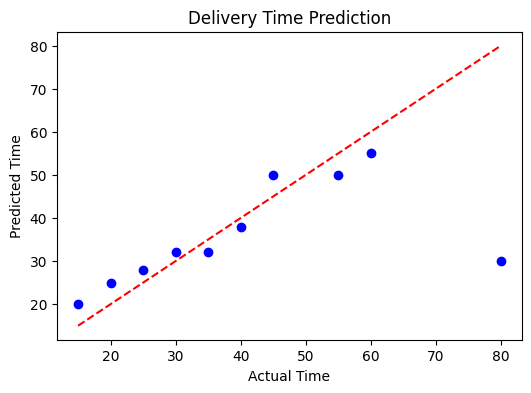


[예제 2: 도어락 안면 인식 성능 분석]
              precision    recall  f1-score   support

       Minsu       0.67      0.67      0.67         3
    Yoonjung       0.60      0.75      0.67         4
       Jimin       1.00      0.67      0.80         3

    accuracy                           0.70        10
   macro avg       0.76      0.69      0.71        10
weighted avg       0.74      0.70      0.71        10



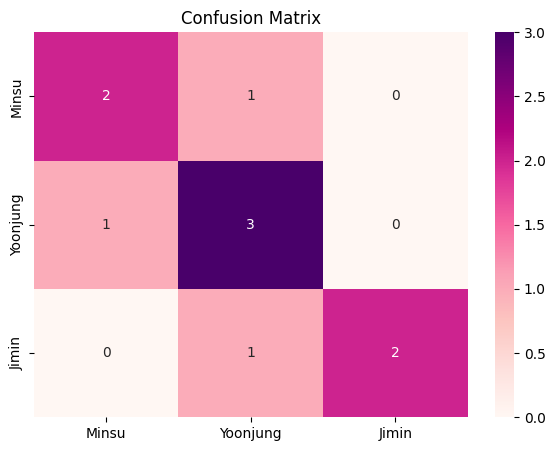

In [86]:
# ==========================================
# 12주차. 머신러닝 알고리즘 평가
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix


# [예제 1] 배달 시간 예측 (회귀 모델 평가)
print("\n[예제 1: 배달 시간 예측 성능 분석]")

# 데이터 설정
actual_time = [20, 35, 15, 45, 60, 25, 40, 55, 30, 80]  # 실제 배달 걸린 시간
predict_time = [25, 32, 20, 50, 55, 28, 38, 50, 32, 30] # 앱이 예고한 시간

# 평가지표 계산
mae = mean_absolute_error(actual_time, predict_time)
mse = mean_squared_error(actual_time, predict_time)
rmse = np.sqrt(mse)
r2 = r2_score(actual_time, predict_time)

print(f"평균 절대 오차 (MAE): {mae:.1f}분")
print(f"예측 모델의 신뢰도 (R2 Score): {r2*100:.1f}%")

# 시각화 (산점도 및 회귀선)
plt.figure(figsize=(6, 4))
plt.scatter(actual_time, predict_time, color='blue')
plt.plot([min(actual_time), max(actual_time)], [min(actual_time), max(actual_time)], 'r--')
plt.xlabel('Actual Time')
plt.ylabel('Predicted Time')
plt.title('Delivery Time Prediction')
plt.show()

# [예제 2] 도어락 얼굴 인식 (분류 모델 평가)
print("\n[예제 2: 도어락 안면 인식 성능 분석]")

# 데이터 설정 (0:민수, 1:윤정, 2:지민)
y_true = [0, 0, 1, 1, 1, 2, 2, 2, 0, 1]
y_pred = [0, 1, 1, 1, 0, 2, 2, 1, 0, 1]
target_names = ['Minsu', 'Yoonjung', 'Jimin'] # 한글 대신 영어 사용 (폰트 문제 방지)

# 상세 보고서 출력
print(classification_report(y_true, y_pred, target_names=target_names))

# 혼동 행렬(Confusion Matrix) 시각화
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, cmap='RdPu', fmt='d',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix')
plt.show()

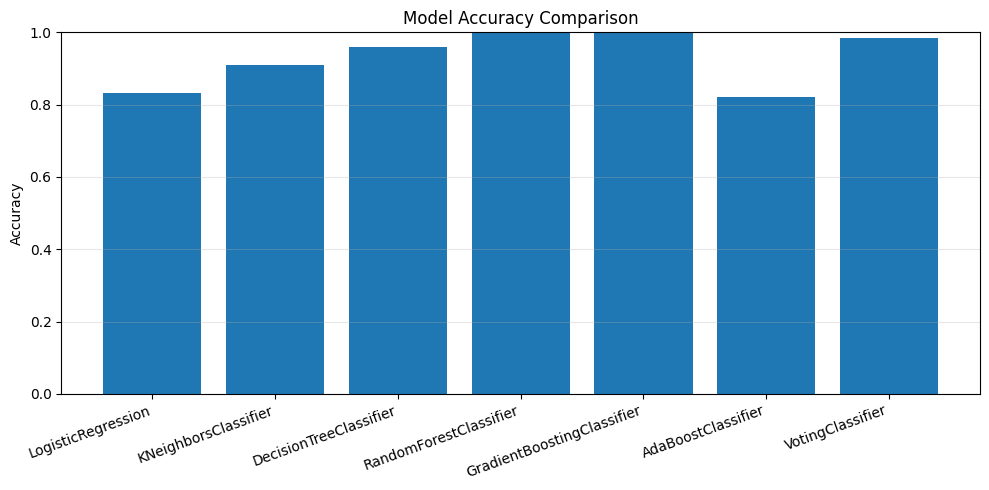

In [87]:
# ==========================================
# 13주차. Ensemble Learning
# ==========================================

# 1. 데이터 로드 (업로드한 customer_churn... 파일 사용)
# 파일 경로는 본인의 환경에 맞게 수정하세요.
df = pd.read_csv('/content/drive/MyDrive/customer_churn_dataset-testing-master.csv')

# 2. 데이터 전처리
# 범주형 데이터를 수치형으로 변환
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})
df['Subscription Type'] = df['Subscription Type'].map({'Basic': 0, 'Standard': 1, 'Premium': 2})
df['Contract Length'] = df['Contract Length'].map({'Monthly': 0, 'Quarterly': 1, 'Annual': 2})

# 이미지 예제와 동일하게 불필요한 CustomerID 컬럼 제거
if 'CustomerID' in df.columns:
    df.drop(columns=['CustomerID'], inplace=True)

# 3. 데이터 분할
feature = df.drop('Churn', axis=1)
target = df['Churn']
train_feature, test_feature, train_label, test_label = train_test_split(
    feature, target, test_size=0.2, random_state=42
)

# 4. 데이터 표준화
scaler = StandardScaler()
train_feature = scaler.fit_transform(train_feature)
test_feature = scaler.transform(test_feature)

# 5. 개별 모델 및 소프트 보팅 앙상블 설정
lr_clf = LogisticRegression()
knn_clf = KNeighborsClassifier(n_neighbors=5)
tree_clf = DecisionTreeClassifier(max_depth=5)
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10)
gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1)
ab_clf = AdaBoostClassifier(n_estimators=50, learning_rate=0.1)

voting_clf = VotingClassifier(
    estimators=[('LR', lr_clf), ('KNN', knn_clf), ('DT', tree_clf), ('RF', rf_clf), ('GB', gb_clf), ('AB', ab_clf)],
    voting='soft'
)

# 6. 모델 학습 및 정확도 기록
models = [lr_clf, knn_clf, tree_clf, rf_clf, gb_clf, ab_clf, voting_clf]
accs = []
names = []

for model in models:
    model.fit(train_feature, train_label)
    pred = model.predict(test_feature)

    # 모델의 클래스명을 리스트에 추가
    names.append(model.__class__.__name__)
    accs.append(accuracy_score(test_label, pred))

# 7. 결과 시각화
plt.figure(figsize=(10, 5))
plt.bar(names, accs)
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20, ha='right') # 라벨 겹침 방지
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

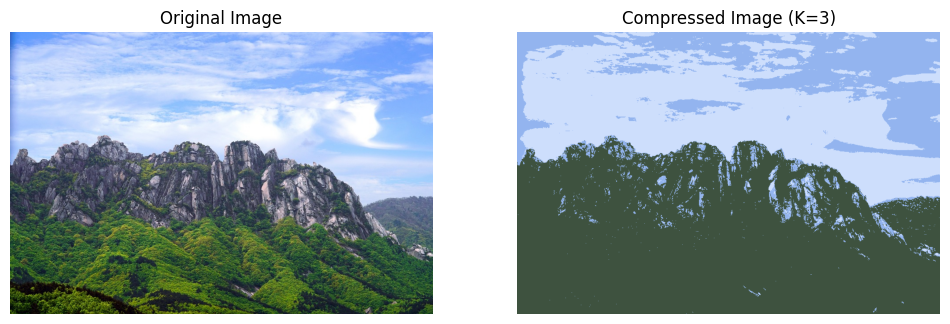

In [88]:
# ==========================================
# 14주차. Clustering (K-Means)
# ==========================================

# 1. 이미지 로드 (업로드한 land.jpg 사용)
# 파일이 코랩 루트 폴더에 있어야 합니다.
try:
    img = Image.open('/content/drive/MyDrive/land.jpg')

    # 2. 이미지 전처리
    # 픽셀 값을 0~1 사이로 정규화하고 2차원 배열로 변환
    img_np = np.array(img) / 255.0
    w, h, d = img_np.shape
    image_array = img_np.reshape(-1, d)

    # 3. K-Means 군집화 적용 (K=3: 색상을 3개로 압축)
    K = 3
    kmeans = KMeans(n_clusters=K, random_state=42)
    kmeans.fit(image_array)

    # 4. 각 픽셀을 가장 가까운 군집 중심 색상으로 치환
    new_colors = kmeans.cluster_centers_[kmeans.predict(image_array)]
    compressed_img = new_colors.reshape(w, h, d)

    # 5. 결과 시각화 (원본 vs 압축본)
    plt.figure(figsize=(12, 6))

    # 원본 이미지 출력
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(img_np)
    plt.axis('off')

    # 압축 이미지 출력
    plt.subplot(1, 2, 2)
    plt.title(f"Compressed Image (K={K})")
    plt.imshow(compressed_img)
    plt.axis('off')

    plt.show()

except FileNotFoundError:
    print("land.jpg 파일이 없습니다. 파일을 업로드하거나 경로를 확인해 주세요.")